<a href="https://colab.research.google.com/github/dhiru69-tech/ML-Techniques-Lab-Project/blob/main/notebooks/day03_eda_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Day 3: EDA with** **Graphs**


**Course:** BO CDA 205, Machine Learning Techniques
**Dataset:** German Credit (1000 customers, 21 columns)
**Syllabus link:** Foundation (visual exploration before feature selection and modelling)

> **Goal of today:** See the shape of each feature, and check which features separate good customers from bad ones.

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Load the German Credit dataset as a table
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame

# Sanity check: should print (1000, 21)
print(df.shape)

# Separate numeric and categorical column names
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
cat_cols.remove('class')   # 'class' is our target, so we keep it out of the feature list
print("Numeric:", num_cols)
print("Categorical features:", cat_cols)

(1000, 21)
Numeric: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


## 2. Distribution of Numeric Features

**Distribution:** the overall shape of the data, showing which values are common and which are rare.

**Histogram:** splits the range into **bins** (boxes) and counts how many rows fall in each bin.

> **What to look for:**
> - A tall bar on the left with a long tail on the right = **right skew**
> - Bars spread evenly = fairly uniform data
> - Few distinct bars (like 1, 2, 3, 4) = the column is really a **category stored as a number**

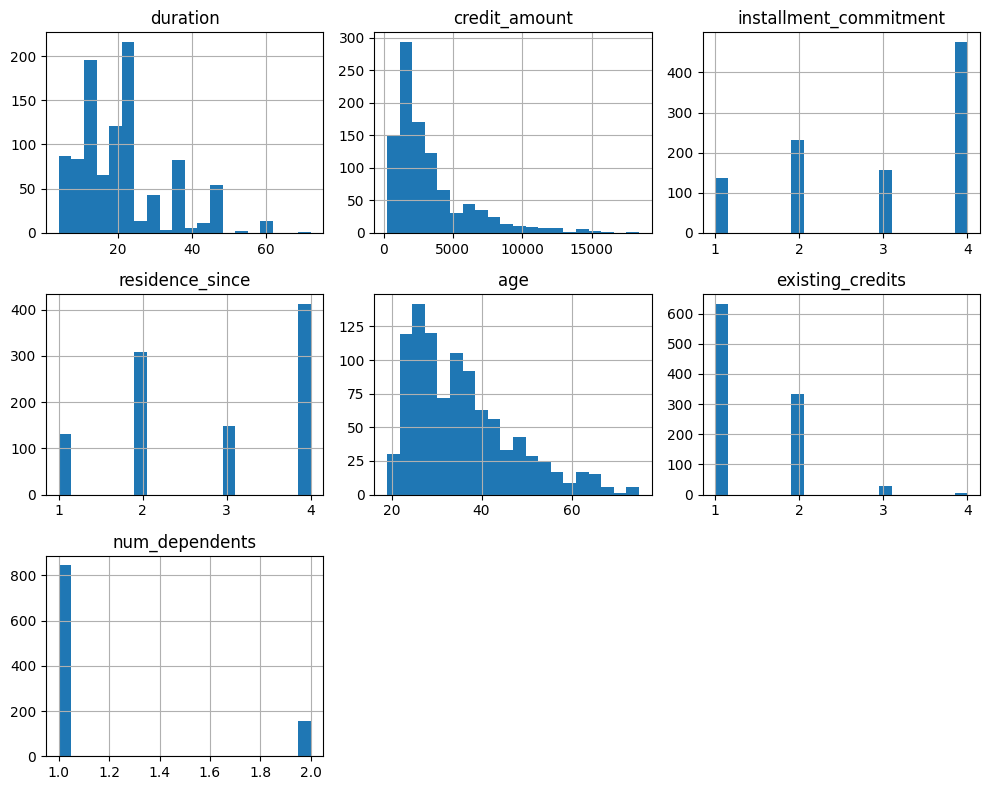

In [ ]:
# Draw one histogram for every numeric column in a single line
# bins=20 -> split each column's range into 20 boxes
# figsize=(12, 8) -> width 12, height 8 (in inches)
df[num_cols].hist(bins=20, figsize=(10, 8))

# tight_layout() stops the small graphs from overlapping each other
plt.tight_layout()
plt.show()

## 3. Numeric Features vs Target (Good / Bad)

We compare the numbers of good customers against bad customers.

**Boxplot recap:** the box holds the middle 50% of the data, the line inside is the **median**, and dots outside are **outliers**.

> **Idea:** if the good box and the bad box sit at **different heights**, that feature helps separate the two groups.

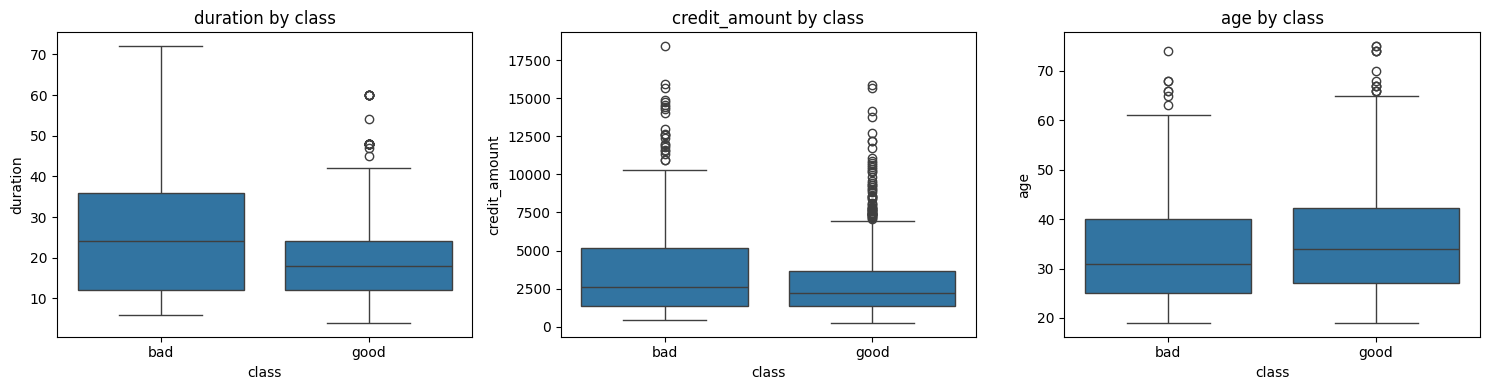

In [ ]:
# Three features we want to compare
features = ['duration', 'credit_amount', 'age']

# Make a canvas with 1 row and 3 columns of graphs
# fig = the whole canvas, axes = the list of 3 small graph areas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# enumerate gives us both the position (i = 0, 1, 2) and the name (col)
for i, col in enumerate(features):
    # x = class (good / bad), y = the numeric feature
    # ax=axes[i] means "draw this graph in the i-th slot"
    sns.boxplot(x='class', y=col, data=df, ax=axes[i])
    axes[i].set_title(col + " by class")

plt.tight_layout()
plt.show()

## 4. Group-wise Averages

**groupby:** splits the table into groups (here: good and bad) and lets us compute something for each group.

This gives exact numbers to back up what the boxplots show visually.

In [ ]:
# Split rows into 'good' and 'bad', then take the average of each numeric column
# round(2) keeps only 2 digits after the decimal point
print(df.groupby('class')[num_cols].mean().round(2))

       duration  credit_amount  installment_commitment  residence_since  \
class                                                                     
bad       24.86        3938.13                    3.10             2.85   
good      19.21        2985.46                    2.92             2.84   

         age  existing_credits  num_dependents  
class                                           
bad    33.96              1.37            1.15  
good   36.22              1.42            1.16  


/tmp/ipykernel_1176/3085782511.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('class')[num_cols].mean().round(2))


## 5. Categorical Features vs Target

**hue:** colors the bars by another column. Here it splits each bar into good (one color) and bad (another color).

**Crosstab:** a table that counts how many good and bad customers fall in each category. With `normalize='index'` it shows **percentages within each category**.

> **Why percentages?** A category may have many bad customers just because it has many customers overall. The percentage tells us the **bad rate** inside each category, which is the fair comparison.

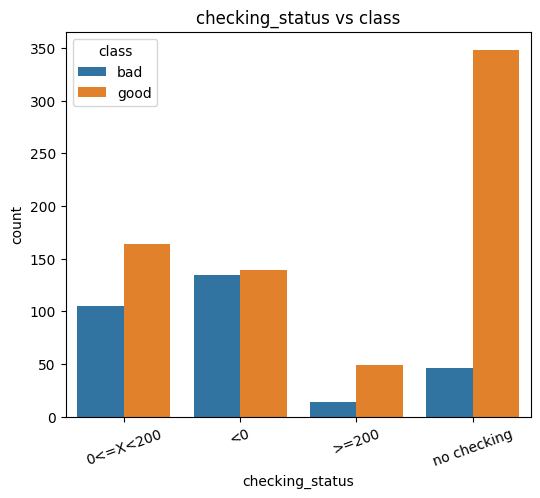

In [ ]:
# Bars for each checking_status category, split by good / bad
plt.figure(figsize=(6,5))
sns.countplot(x='checking_status', hue='class', data=df)
plt.title("checking_status vs class")

# Category names are long, so tilt them 20 degrees to avoid overlap
plt.xticks(rotation=20)
plt.show()

In [ ]:
# Percentage of good and bad inside each checking_status category
table = pd.crosstab(df['checking_status'], df['class'], normalize='index') * 100
print(table.round(1))

class             bad  good
checking_status            
0<=X<200         39.0  61.0
<0               49.3  50.7
>=200            22.2  77.8
no checking      11.7  88.3


In [ ]:
# Loop over a few more categorical features and print the bad-rate table for each
for col in ['credit_history', 'savings_status', 'housing']:
    print("Feature:", col)
    print((pd.crosstab(df[col], df['class'], normalize='index') * 100).round(1))
    print()   # blank line between tables

Feature: credit_history
class                            bad  good
credit_history                            
all paid                        57.1  42.9
critical/other existing credit  17.1  82.9
delayed previously              31.8  68.2
existing paid                   31.9  68.1
no credits/all paid             62.5  37.5

Feature: savings_status
class              bad  good
savings_status              
100<=X<500        33.0  67.0
500<=X<1000       17.5  82.5
<100              36.0  64.0
>=1000            12.5  87.5
no known savings  17.5  82.5

Feature: housing
class      bad  good
housing             
for free  40.7  59.3
own       26.1  73.9
rent      39.1  60.9



## Day 3 Observations (my own words)
1. Right-skewed columns: credit_amount, duration
2. Columns that look like small categories stored as numbers: installment_commitment, residence_since, existing_credits, num_dependents
3. Bad customers have higher duration than good ones: higher (loans are longer)
4. Bad customers have higher credit_amount: higher (bigger loans)
5. In checking_status, highest bad rate is in category <0 (__%), lowest in no checking (__%)
6. Feature that seems most useful for separating good and bad: checking_status

## What I learned today
- A histogram shows the shape of a feature, and a boxplot compares good vs bad.
- Percentages inside each category (crosstab) are a fairer comparison than raw counts.
- Correlation is not causation.